In [3]:
import json
import csv
import os

# -------- CONFIG --------
INPUT_DIR = "../output/rq2_stability/reports"
OUTPUT_CSV = "deltaN_reports.csv"
# ------------------------

rows = []

for filename in os.listdir(INPUT_DIR):
    if not filename.endswith(".json"):
        continue

    file_path = os.path.join(INPUT_DIR, filename)

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    noisy_variant = data.get("meta", {}).get("noisy_variant")

    stability_items = (
        data
        .get("analysis", {})
        .get("stability_analysis", [])
    )

    for item in stability_items:
        row = {
            "noisy_variant": noisy_variant,
            "ref_fact_id": item.get("ref_fact_id"),
            "status": item.get("status"),
            "candidate_match_id": item.get("candidate_match_id"),
            "reasoning": item.get("reasoning"),
            "source_file": filename
        }
        rows.append(row)

# Write CSV
fieldnames = [
    "noisy_variant",
    "ref_fact_id",
    "status",
    "candidate_match_id",
    "reasoning",
    "source_file"
]

with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"Wrote {len(rows)} rows to {OUTPUT_CSV}")


Wrote 1684 rows to deltaN_reports.csv


In [2]:
df = pd.read_csv("deltaN_reports_with_error_meta.csv")
df['noisy_variant'].unique()

NameError: name 'pd' is not defined

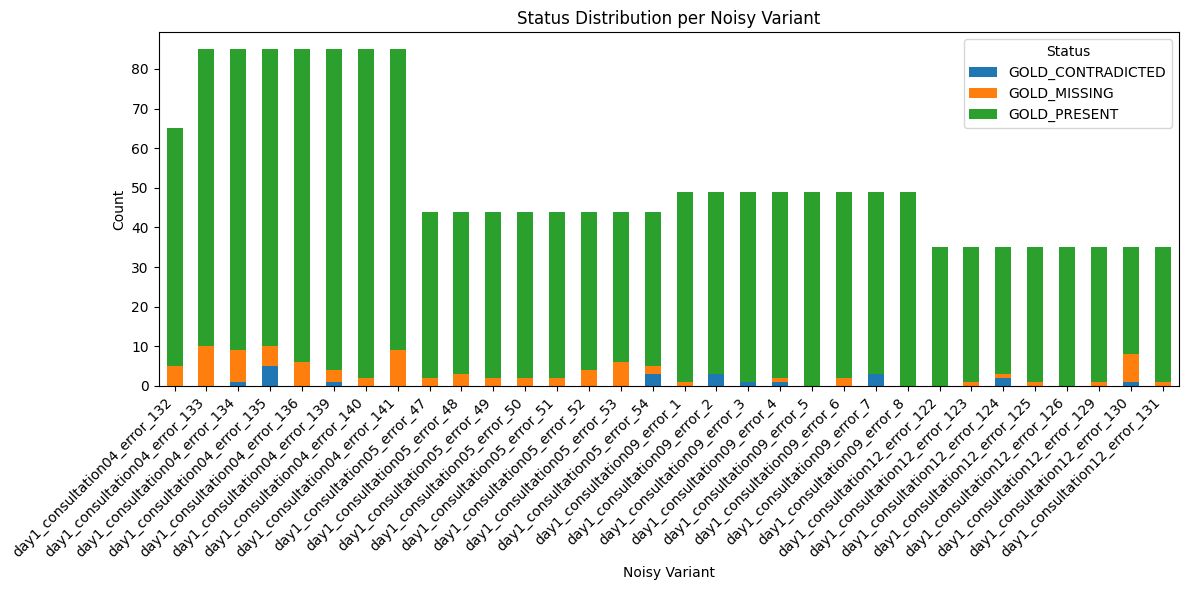

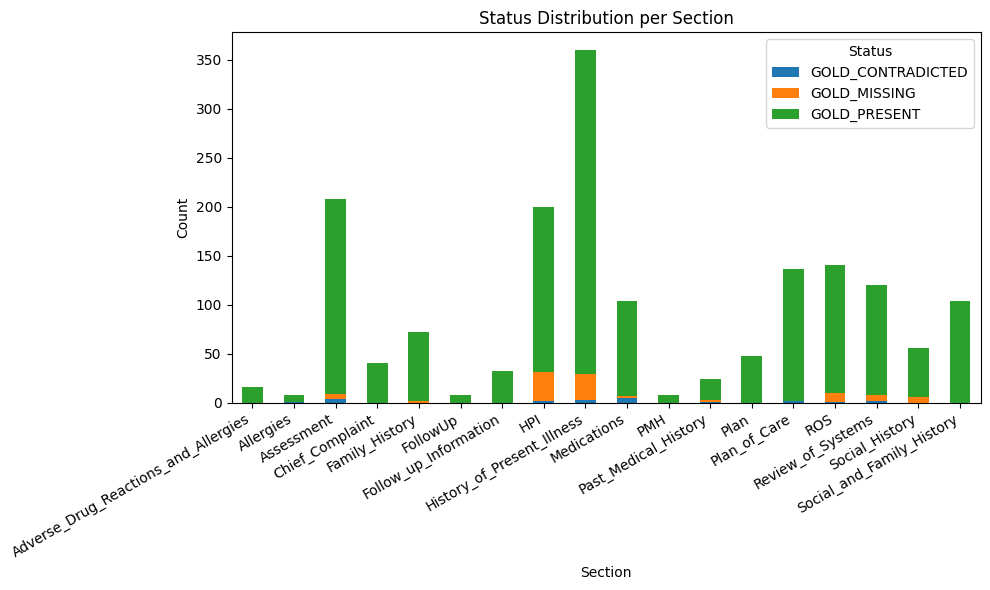

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# -------- CONFIG --------
CSV_PATH = "deltaN_reports.csv"
# ------------------------

# Load data
df = pd.read_csv(CSV_PATH)
df['status'] = df['status'].replace({'PRESERVED': 'GOLD_PRESENT', 'OMITTED': 'GOLD_MISSING', 'CONTRADICTED': 'GOLD_CONTRADICTED'})
df.to_csv(CSV_PATH, index=False)  # Update CSV with new status labels
# --------------------------------------
# 1. Status distribution per noisy_variant
# --------------------------------------

status_by_variant = (
    df
    .groupby(["noisy_variant", "status"])
    .size()
    .unstack(fill_value=0)
)

# Plot
status_by_variant.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Status Distribution per Noisy Variant")
plt.xlabel("Noisy Variant")
plt.ylabel("Count")
plt.legend(title="Status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --------------------------------------
# 2. Status distribution per section
#    (ref_fact_id before '-')
# --------------------------------------

# Extract section name
df["section"] = df["ref_fact_id"].str.split("-").str[0]

status_by_section = (
    df
    .groupby(["section", "status"])
    .size()
    .unstack(fill_value=0)
)

# Plot
status_by_section.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Status Distribution per Section")
plt.xlabel("Section")
plt.ylabel("Count")
plt.legend(title="Status")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import re

# -------- CONFIG --------
REPORTS_CSV = "deltaN_reports.csv"
ERRORS_CSV = "final_all_consults_errors.csv"
OUTPUT_CSV = "deltaN_reports_with_error_type.csv"
# ------------------------

# Load CSVs
reports_df = pd.read_csv(REPORTS_CSV)
errors_df = pd.read_csv(ERRORS_CSV)

# ---------------------------------------
# Extract error_id from noisy_variant
# e.g. day1_consultation05_error_48 -> 48
# ---------------------------------------
reports_df["error_id"] = (
    reports_df["noisy_variant"]
    .str.extract(r"_error_(\d+)")
    .astype(float)   # allows NaN if no match
)

# Ensure error_id types align
errors_df["error_id"] = errors_df["error_id"].astype(float)

# ---------------------------------------
# Join to bring in error_type
# ---------------------------------------
merged_df = reports_df.merge(
    errors_df[["error_id", "error_type"]],
    on="error_id",
    how="left"
)

# ---------------------------------------
# Save result
# ---------------------------------------
merged_df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved merged file to {OUTPUT_CSV}")
print(f"Rows: {len(merged_df)}")
print(f"Missing error_type: {merged_df['error_type'].isna().sum()}")


Saved merged file to deltaN_reports_with_error_type.csv
Rows: 1684
Missing error_type: 0


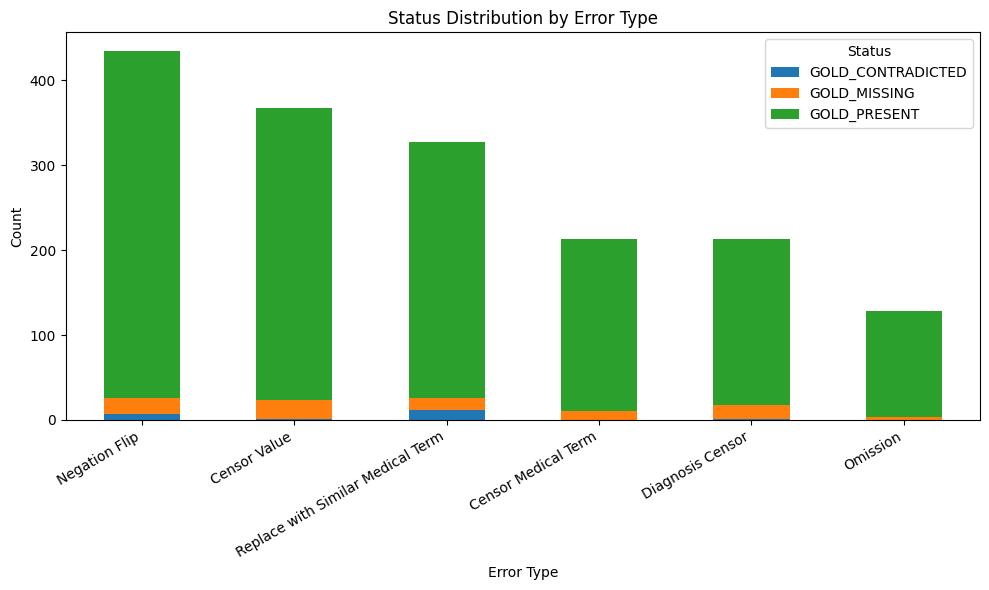

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# -------- CONFIG --------
CSV_PATH = "deltaN_reports_with_error_type.csv"
# ------------------------

# Load data
df = pd.read_csv(CSV_PATH)

# Drop rows where error_type is missing (optional but usually desired)
df = df.dropna(subset=["error_type"])

# --------------------------------------
# Group and count
# --------------------------------------
status_by_error_type = (
    df
    .groupby(["error_type", "status"])
    .size()
    .unstack(fill_value=0)
)

# Optional: sort error types by total count
status_by_error_type = status_by_error_type.loc[
    status_by_error_type.sum(axis=1).sort_values(ascending=False).index
]

# --------------------------------------
# Plot
# --------------------------------------
status_by_error_type.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Status Distribution by Error Type")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.legend(title="Status")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


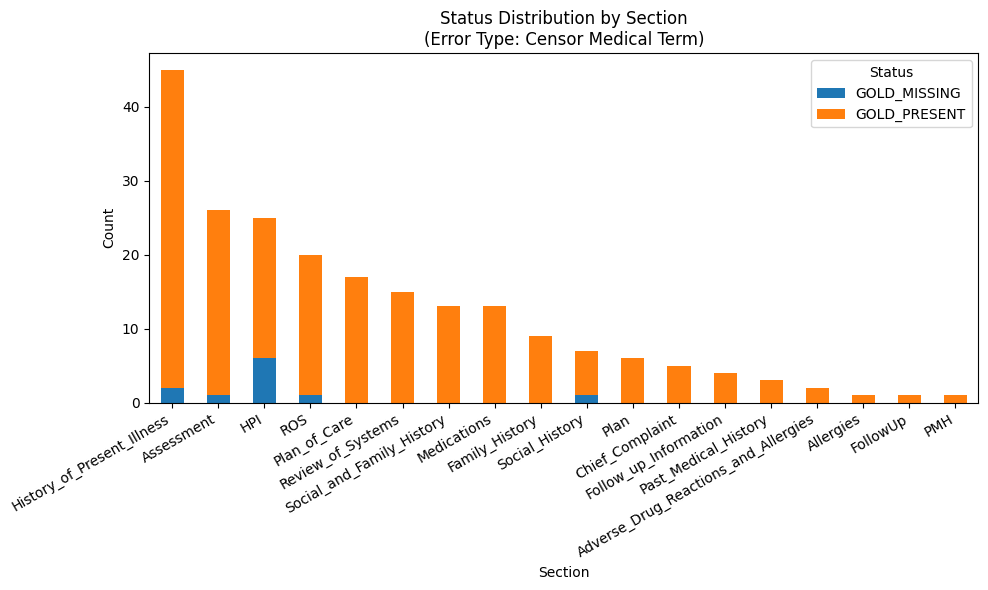

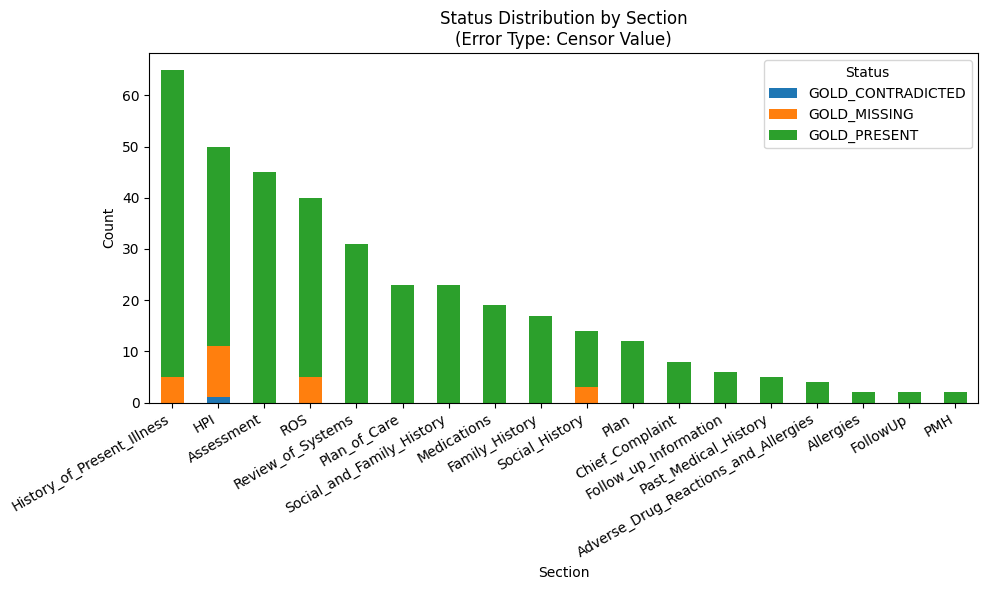

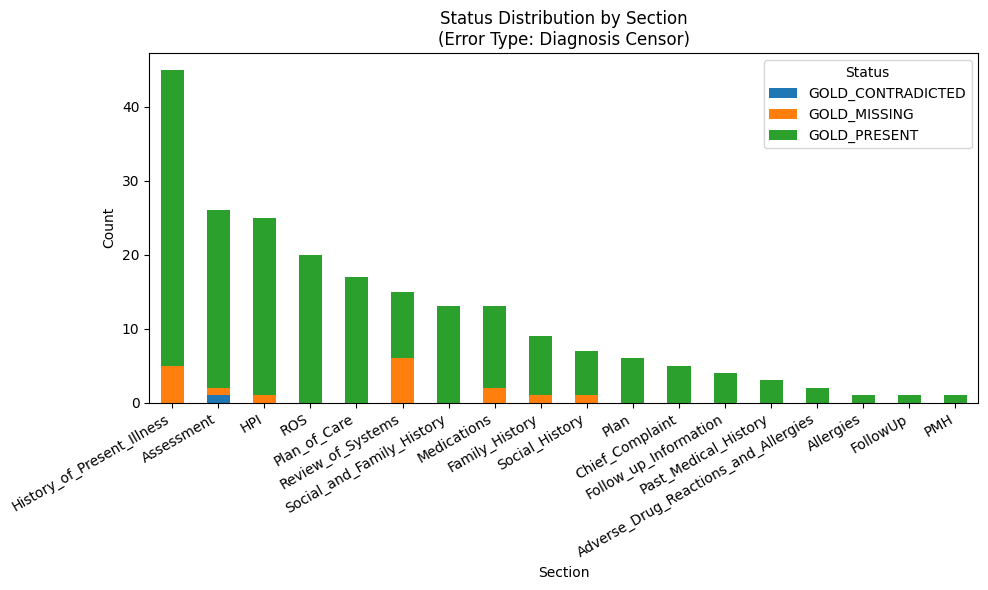

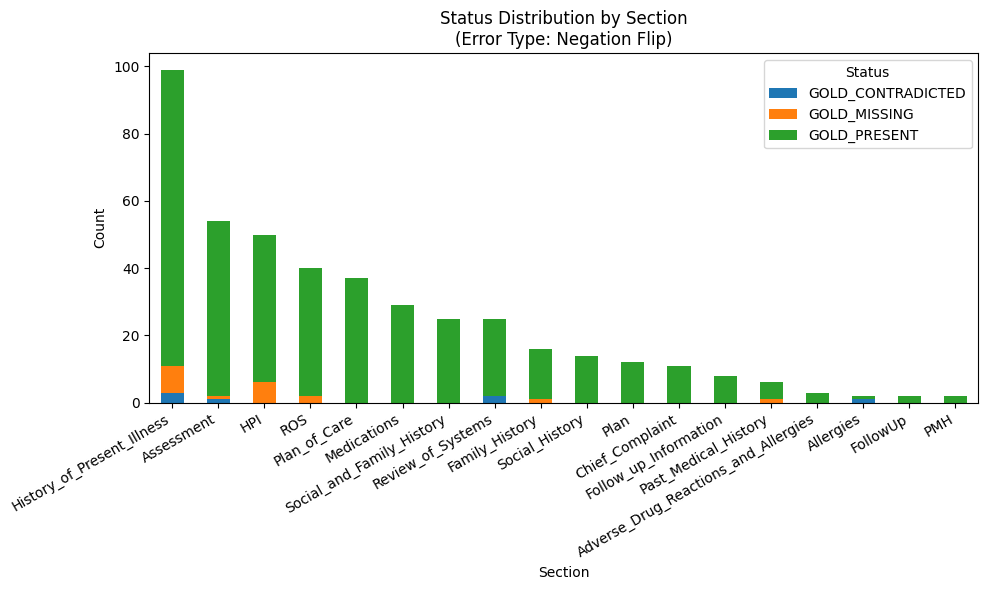

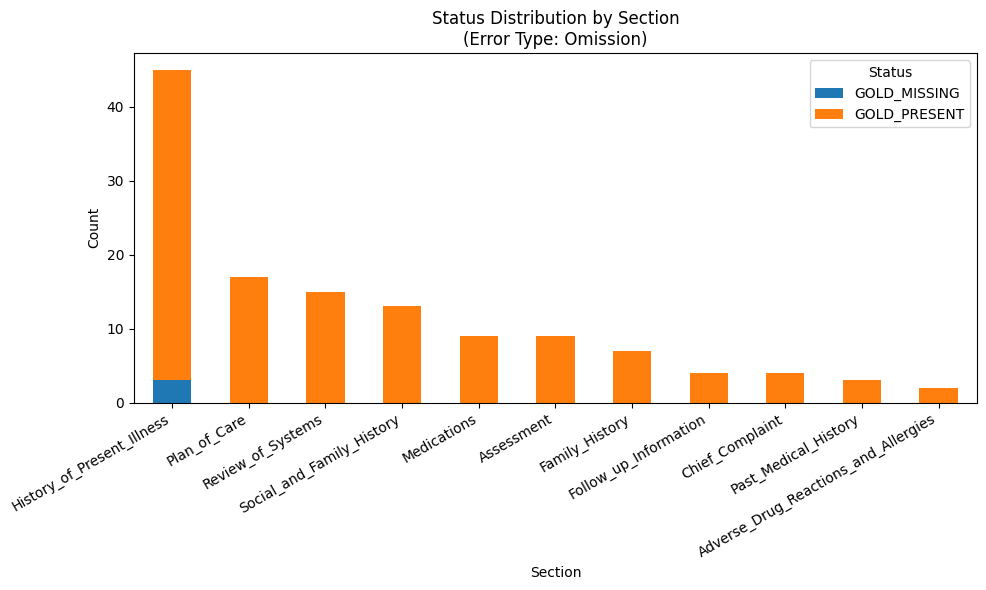

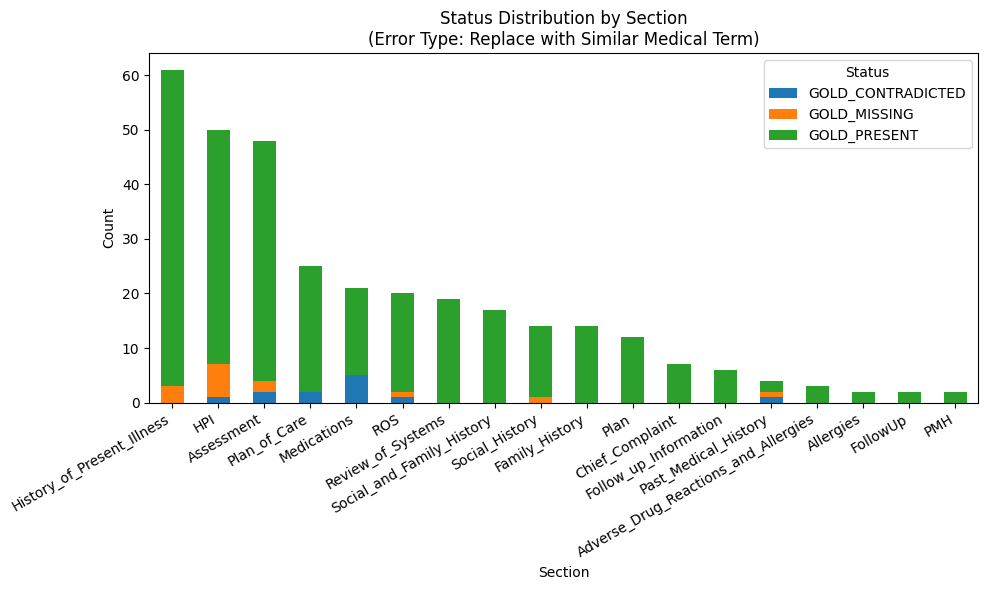

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# -------- CONFIG --------
CSV_PATH = "deltaN_reports_with_error_type.csv"
# ------------------------

# Load data
df = pd.read_csv(CSV_PATH)

# Keep only rows with error_type
df = df.dropna(subset=["error_type"])

# Extract section from ref_fact_id (before '-')
df["section"] = df["ref_fact_id"].str.split("-").str[0]

# --------------------------------------
# Plot per error_type
# --------------------------------------
for error_type, sub_df in df.groupby("error_type"):

    counts = (
        sub_df
        .groupby(["section", "status"])
        .size()
        .unstack(fill_value=0)
    )

    # Optional: sort sections by total count
    counts = counts.loc[
        counts.sum(axis=1).sort_values(ascending=False).index
    ]

    counts.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6)
    )

    plt.title(f"Status Distribution by Section\n(Error Type: {error_type})")
    plt.xlabel("Section")
    plt.ylabel("Count")
    plt.legend(title="Status")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


In [8]:
import pandas as pd

# -------- CONFIG --------
REPORTS_CSV = "deltaN_reports_with_error_type.csv"
ERRORS_CSV = "final_all_consults_errors.csv"
OUTPUT_CSV = "deltaN_reports_with_error_meta.csv"
# ------------------------

# Load data
reports_df = pd.read_csv(REPORTS_CSV)
errors_df = pd.read_csv(ERRORS_CSV)

# Ensure error_id types match
reports_df["error_id"] = reports_df["error_id"].astype(float)
errors_df["error_id"] = errors_df["error_id"].astype(float)

# Select and rename section field
errors_subset = (
    errors_df[["error_id", "section"]]
    .rename(columns={"section": "error_section"})
)

# Join
merged_df = reports_df.merge(
    errors_subset,
    on="error_id",
    how="left"
)

# Save
merged_df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved updated CSV to {OUTPUT_CSV}")
print(f"Rows with missing error_section: {merged_df['error_section'].isna().sum()}")


Saved updated CSV to deltaN_reports_with_error_meta.csv
Rows with missing error_section: 0


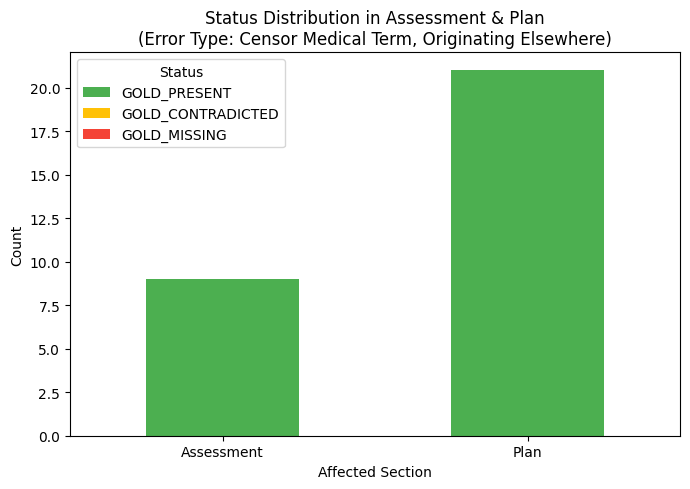

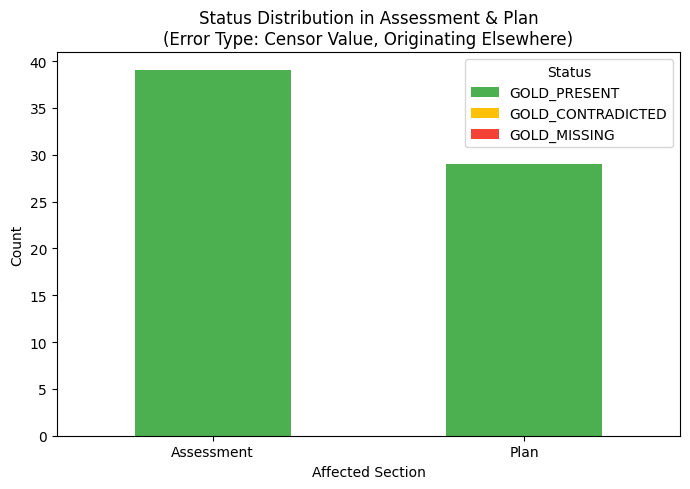

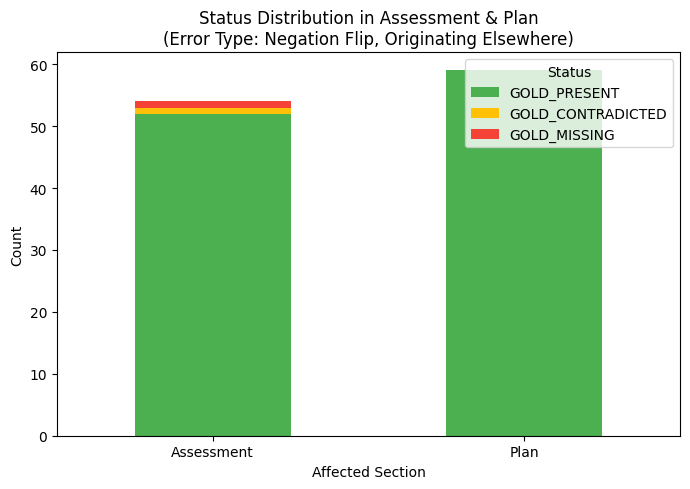

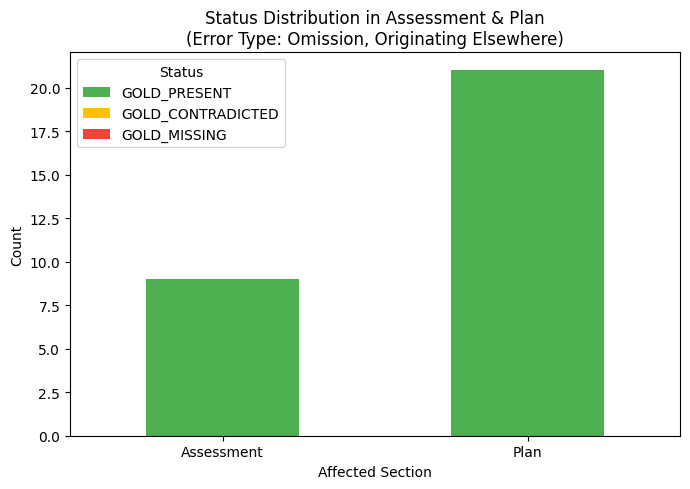

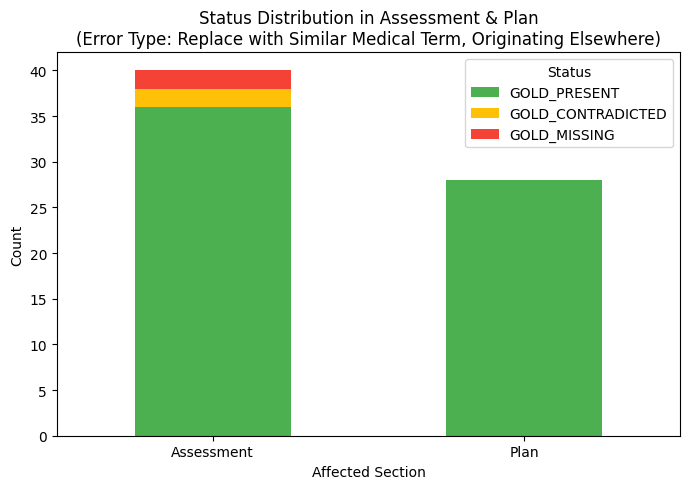

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------- CONFIG --------
CSV_PATH = "deltaN_reports_with_error_meta.csv"
TARGET_SECTIONS = {"Assessment", "Plan", "Plan_of_Care", "Follow_up_Information", "FollowUp" }
TARGET_SUBSET = {"Assessment", "Plan" }
# ------------------------
df = pd.read_csv(CSV_PATH)

# Derive affected section from ref_fact_id
df["affected_section"] = df["ref_fact_id"].str.split("-").str[0]
df['affected_section'] = df['affected_section'].replace({'Plan_of_Care': 'Plan', 'Follow_up_Information': 'Plan', 'FollowUp': 'Plan' })

# --------------------------------------
# Filter:
# - errors originating OUTSIDE Assessment/Plan
# - effects INSIDE Assessment/Plan
# --------------------------------------
filtered_df = df[
    (~df["error_section"].isin(TARGET_SECTIONS)) &
    (df["affected_section"].isin(TARGET_SECTIONS))
]

# Define a GLOBAL, CONSISTENT color map for status
STATUS_COLORS = {
    "GOLD_PRESENT": "#4CAF50",   # green
    "GOLD_CONTRADICTED":   "#FFC107",   # amber
    "GOLD_MISSING":   "#F44336",   # red
    "NEW_ADDITION":     "#2196F3",   # blue (if applicable)
}
# ------------------------

# Determine global status order (only those present)
status_order = [s for s in STATUS_COLORS if s in filtered_df["status"].unique()]

# --------------------------------------
# Plot per error_type
# --------------------------------------
for error_type, sub_df in filtered_df.groupby("error_type"):

    counts = (
        sub_df
        .groupby(["affected_section", "status"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=TARGET_SUBSET, columns=status_order, fill_value=0)
    )

    counts.plot(
        kind="bar",
        stacked=True,
        figsize=(7, 5),
        color=[STATUS_COLORS[s] for s in counts.columns]
    )

    plt.title(
        f"Status Distribution in Assessment & Plan\n"
        f"(Error Type: {error_type}, Originating Elsewhere)"
    )
    plt.xlabel("Affected Section")
    plt.ylabel("Count")
    plt.legend(title="Status")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
# Filter:
# - errors originating OUTSIDE Assessment/Plan
# - effects INSIDE Assessment/Plan
# - status NOT GOLD_PRESENT
GOLD_STATUS = "GOLD_PRESENT"

filtered_df = df[
    (~df["error_section"].isin(TARGET_SECTIONS)) &
    (df["affected_section"].isin(TARGET_SECTIONS)) &
    (df["status"] != GOLD_STATUS)
]

# Print results nicely
if filtered_df.empty:
    print("No entries found meeting the criteria.")
else:
    print(f"Found {len(filtered_df)} entries where status != {GOLD_STATUS}:")
    # Print each row on a single line
    for _, row in filtered_df.iterrows():
        print(row.to_dict())


Found 6 entries where status != GOLD_PRESENT:
{'noisy_variant': 'day1_consultation04_error_136', 'ref_fact_id': 'Assessment-011', 'status': 'GOLD_MISSING', 'candidate_match_id': nan, 'reasoning': 'Denial of chest pain is not present in the candidate.', 'source_file': 'day1_consultation04_error_136_diff.json', 'error_id': 136.0, 'error_type': 'Negation Flip', 'error_section': 'History_of_Present_Illness', 'affected_section': 'Assessment'}
{'noisy_variant': 'day1_consultation04_error_132', 'ref_fact_id': 'Assessment-017', 'status': 'GOLD_MISSING', 'candidate_match_id': nan, 'reasoning': 'Reference mentions ear examination negative by history, but Candidate does not.', 'source_file': 'day1_consultation04_error_132_diff.json', 'error_id': 132.0, 'error_type': 'Replace with Similar Medical Term', 'error_section': 'Chief_Complaint', 'affected_section': 'Assessment'}
{'noisy_variant': 'day1_consultation09_error_2', 'ref_fact_id': 'Assessment-003', 'status': 'GOLD_CONTRADICTED', 'candidate_mat

In [ ]:
REF_FACTS_DIR = "../output/clean_notes_facts"  # folder with clean JSONs

if filtered_df.empty:
    print("No entries found meeting the criteria.")
else:
    print(f"Found {len(filtered_df)} entries where status != {GOLD_STATUS}.")

# --------------------------------------
# Function to fetch the clean fact content
# --------------------------------------
def fetch_fact_content(noisy_variant, ref_fact_id):
    clean_filename_base = re.sub(r"_error_\d+$", "", noisy_variant)
    clean_json_path = os.path.join(REF_FACTS_DIR, f"{clean_filename_base}.json")
    
    if not os.path.exists(clean_json_path):
        return None

    with open(clean_json_path, "r", encoding="utf-8") as f:
        clean_data = json.load(f)
    
    section = ref_fact_id.split("-")[0]
    facts_in_section = clean_data.get(section, [])
    for fact in facts_in_section:
        if fact.get("fact_id") == ref_fact_id:
            return fact.get("content") or fact.get("source_text")
    
    return None

# Apply function
filtered_df["fact_content"] = filtered_df.apply(
    lambda row: fetch_fact_content(row["noisy_variant"], row["ref_fact_id"]),
    axis=1
)

# --------------------------------------
# Display fully without truncation
# --------------------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)  # do not truncate long text
pd.set_option('display.width', 1000)        # adjust console width

print(filtered_df[["noisy_variant", "ref_fact_id", "fact_content"]])

Found 6 entries where status != GOLD_PRESENT.
                      noisy_variant     ref_fact_id                                                 fact_content
343   day1_consultation04_error_136  Assessment-011                                            Denies chest pain
929   day1_consultation04_error_132  Assessment-017                          Ear examination negative by history
1503    day1_consultation09_error_2  Assessment-003  Afebrile with no nausea, vomiting, flank pain, or back pain
1606  day1_consultation04_error_135  Assessment-002                  Four days of sore throat which is improving
1610  day1_consultation04_error_135  Assessment-006        Initial fever responsive to paracetamol and ibuprofen
1621  day1_consultation04_error_135  Assessment-017                          Ear examination negative by history


/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_66319/2977653200.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["fact_content"] = filtered_df.apply(


In [ ]:
import pandas as pd
import json
import os
import re

# -------- CONFIG --------
CSV_PATH = "deltaN_reports_with_error_meta.csv"
REF_FACTS_DIR = "../output/clean_notes_facts"
TARGET_SECTIONS = {"Assessment", "Plan", "Plan_of_Care", "Follow_up_Information", "FollowUp"}
GOLD_STATUS = "GOLD_PRESENT"
# ------------------------

# Load CSV
df = pd.read_csv(CSV_PATH)

# Derive affected section and standardize
df["affected_section"] = df["ref_fact_id"].str.split("-").str[0]
df["affected_section"] = df["affected_section"].replace({
    "Plan_of_Care": "Plan",
    "Follow_up_Information": "Plan",
    "FollowUp": "Plan"
})

# Filter rows
filtered_df = df[
    (~df["error_section"].isin(TARGET_SECTIONS)) &
    (df["affected_section"].isin({"Assessment", "Plan"})) &
    (df["status"] != GOLD_STATUS)
]

# --------------------------------------
# Function to fetch the clean fact content
# --------------------------------------
def fetch_fact_content(noisy_variant, ref_fact_id):
    """
    Fetch content or source_text for a given fact_id from the clean JSON.
    """
    clean_filename_base = re.sub(r"_error_\d+$", "", noisy_variant)
    clean_json_path = os.path.join(REF_FACTS_DIR, f"{clean_filename_base}.json")
    
    if not os.path.exists(clean_json_path):
        return None

    with open(clean_json_path, "r", encoding="utf-8") as f:
        clean_data = json.load(f)
    
    section = ref_fact_id.split("-")[0]
    facts_in_section = clean_data.get(section, [])
    for fact in facts_in_section:
        if fact.get("fact_id") == ref_fact_id:
            return fact.get("content") or fact.get("source_text")
    
    return None

# Apply function to get fact content
filtered_df["fact_content"] = filtered_df.apply(
    lambda row: fetch_fact_content(row["noisy_variant"], row["ref_fact_id"]),
    axis=1
)

# --------------------------------------
# Print results nicely, one row per line
# --------------------------------------
if filtered_df.empty:
    print("No entries found meeting the criteria.")
else:
    print(f"Found {len(filtered_df)} entries where status != {GOLD_STATUS}:")
    for _, row in filtered_df.iterrows():
        # Convert row to dict and print full content
        row_dict = row.to_dict()
        print(row_dict)


Found 6 entries where status != GOLD_PRESENT:
{'noisy_variant': 'day1_consultation04_error_136', 'ref_fact_id': 'Assessment-011', 'status': 'GOLD_MISSING', 'candidate_match_id': nan, 'reasoning': 'Denial of chest pain is not present in the candidate.', 'source_file': 'day1_consultation04_error_136_diff.json', 'error_id': 136.0, 'error_type': 'Negation Flip', 'error_section': 'History_of_Present_Illness', 'affected_section': 'Assessment', 'fact_content': 'Denies chest pain'}
{'noisy_variant': 'day1_consultation04_error_132', 'ref_fact_id': 'Assessment-017', 'status': 'GOLD_MISSING', 'candidate_match_id': nan, 'reasoning': 'Reference mentions ear examination negative by history, but Candidate does not.', 'source_file': 'day1_consultation04_error_132_diff.json', 'error_id': 132.0, 'error_type': 'Replace with Similar Medical Term', 'error_section': 'Chief_Complaint', 'affected_section': 'Assessment', 'fact_content': 'Ear examination negative by history'}
{'noisy_variant': 'day1_consultatio

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -------- CONFIG --------
CSV_PATH = "deltaN_reports_with_error_meta.csv"
TARGET_SECTIONS = {"Assessment", "Plan", "Plan_of_Care", "Follow_up_Information", "FollowUp"}
# Map alternative Plan sections to 'Plan'
PLAN_ALIASES = {"Plan_of_Care", "Follow_up_Information", "FollowUp"}

STATUS_COLORS = {
    "GOLD_PRESENT": "#4CAF50",        # green
    "GOLD_CONTRADICTED": "#FFC107",   # amber
    "GOLD_MISSING": "#F44336",        # red
    "NEW_ADDITION": "#2196F3",        # blue
}
# ------------------------

# Load CSV
df = pd.read_csv(CSV_PATH)

# Standardize affected_section
df["affected_section"] = df["ref_fact_id"].str.split("-").str[0]
df["affected_section"] = df["affected_section"].replace({
    "Plan_of_Care": "Plan",
    "Follow_up_Information": "Plan",
    "FollowUp": "Plan"
})

# Standardize error_section similarly
df["error_section"] = df["error_section"].replace({
    "Plan_of_Care": "Plan",
    "Follow_up_Information": "Plan",
    "FollowUp": "Plan"
})

# --------------------------------------
# Assessment -> Plan
# --------------------------------------
assess_to_plan = df[
    (df["error_section"] == "Assessment") &
    (df["affected_section"] == "Plan")
]
print(assess_to_plan.head())

# Plot
if not assess_to_plan.empty:
    counts = assess_to_plan["status"].value_counts().reindex(STATUS_COLORS.keys(), fill_value=0)
    counts.plot(kind="bar", color=[STATUS_COLORS[s] for s in counts.index], figsize=(6,4))
    plt.title("Status Distribution in Plan\n(Errors Originating in Assessment)")
    plt.xlabel("Status")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# --------------------------------------
# Plan -> Assessment
# --------------------------------------
plan_to_assess = df[
    (df["error_section"] == "Plan") &
    (df["affected_section"] == "Assessment")
]

# Plot
if not plan_to_assess.empty:
    counts = plan_to_assess["status"].value_counts().reindex(STATUS_COLORS.keys(), fill_value=0)
    counts.plot(kind="bar", color=[STATUS_COLORS[s] for s in counts.index], figsize=(6,4))
    plt.title("Status Distribution in Assessment\n(Errors Originating in Plan)")
    plt.xlabel("Status")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


Empty DataFrame
Columns: [noisy_variant, ref_fact_id, status, candidate_match_id, reasoning, source_file, error_id, error_type, error_section, affected_section, fact_content]
Index: []


In [9]:
2/32

0.0625